# 0. Stock Direction Classifier

In [18]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import sklearn

In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Data Collection

## 1.1 Download data

In [20]:
ticker = "AAPL"

df = yf.download(ticker, start="2010-01-01", end="2024-01-01")

df = df[["Close"]] # Only keep the 'Close' column
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2010-01-04,6.406481
2010-01-05,6.417556
2010-01-06,6.315478
2010-01-07,6.303801
2010-01-08,6.345711


## 1.2 Plot closing prices

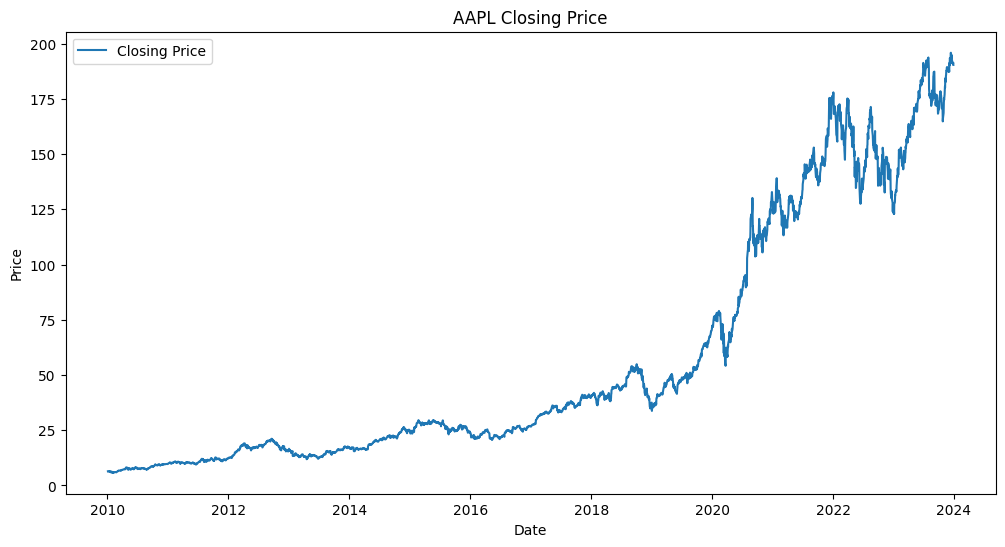

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Close"], label="Closing Price")
plt.title(f"{ticker} Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# 2. Feature Engineering

## 2.1 Log returns

In [22]:
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1)) # Calculate log returns

## 2.2 Technical features

In [23]:
# Mobile averages
df["ma_5"] = df["Close"].rolling(5).mean()
df["ma_20"] = df["Close"].rolling(20).mean()

# Volatility
df["volatility_5"] = df["log_return"].rolling(5).std()
df["volatility_20"] = df["log_return"].rolling(20).std()

# Momentum
df["momentum_5"] = df["log_return"].rolling(5).sum()
df["momentum_20"] = df["log_return"].rolling(20).sum()

# Relative Strength Index (RSI)
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df["rsi"] = compute_rsi(df["Close"])

## 2.3 Target

In [34]:
df["target"] = df["log_return"].shift(-1) # Predict the next day's log return
df["target"].head()
df["target"].tail()

Date
2023-12-22   -0.002845
2023-12-26    0.000518
2023-12-27    0.002224
2023-12-28   -0.005439
2023-12-29         NaN
Name: target, dtype: float64

In [43]:
count = (df["target"] > 0).sum()
print(f"Number of positive returns: {count}/{len(df)}")

Number of positive returns: 1862/3522


# 3. Getting the data ready

## 3.1 X and y

In [46]:
features = ["log_return", "ma_5", "ma_20", "volatility_5", "volatility_20", "momentum_5", "momentum_20", "rsi"]
X = df[features].dropna()
y = df["target"].dropna()

## 3.2 Splitting the data

In [50]:
train_split = (int(len(X) * 0.7))
val_split = (int(len(X) * 0.2))

X_train, y_train = X[:train_split], y[:train_split]
X_val, y_val = X[train_split:train_split+val_split], y[train_split:train_split+val_split]
X_test, y_test = X[train_split+val_split:], y[train_split+val_split:]

len(X_train), len(X_val), len(X_test)

(2451, 700, 351)

## 3.3 Scaling the data

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test) # Only on training data to prevent data leakage

## 3.4 Converting to tensor and senting to device

In [52]:
# Let's convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

C:\Users\simon\AppData\Local\Temp\ipykernel_11940\572063117.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
C:\Users\simon\AppData\Local\Temp\ipykernel_11940\572063117.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)
C:\Users\simon\AppData\Local\Temp\ipykernel_11940\572063117.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a val